Logistic Regression

In [3]:
# ---------------------------------------------------
# 🔹 1. Import required libraries
# ---------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ---------------------------------------------------
# 🔹 2. Load dataset
# ---------------------------------------------------
data = pd.read_csv("diabetes.csv")

# ---------------------------------------------------
# 🔹 3. Separate features (X) and target (y)
# ---------------------------------------------------
X = data.drop('Outcome', axis=1)   # All input features
y = data['Outcome']                # Target (0 = No diabetes, 1 = Diabetes)

# ---------------------------------------------------
# 🔹 4. Train-test split
# ---------------------------------------------------
# 80% training, 20% testing
# stratify ensures same class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# ---------------------------------------------------
# 🔹 5. Feature Scaling
# ---------------------------------------------------
# Logistic Regression distance-based nahi hai strictly,
# but scaling improves convergence and performance

scaler = StandardScaler()

# Fit only on training data (IMPORTANT ❗)
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation on test data
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------
# 🔹 6. Create Logistic Regression model
# ---------------------------------------------------
model = LogisticRegression()

# ---------------------------------------------------
# 🔹 7. Train the model
# ---------------------------------------------------
model.fit(X_train_scaled, y_train)

# ---------------------------------------------------
# 🔹 8. Prediction
# ---------------------------------------------------
y_pred = model.predict(X_test_scaled)

# ---------------------------------------------------
# 🔹 9. Evaluation metrics
# ---------------------------------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# ---------------------------------------------------
# 🔹 10. Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ---------------------------------------------------
# 🔹 11. Class-wise accuracy
# ---------------------------------------------------

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571

Confusion Matrix:
 [[0 1]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
# ---------------------------------------------------
# 🔹 1. Import required libraries
# ---------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# ---------------------------------------------------
# 🔹 2. Load dataset
# ---------------------------------------------------
data = pd.read_csv("diabetes.csv")


# ---------------------------------------------------
# 🔹 3. Separate features (X) and target (y)
# ---------------------------------------------------
X = data.drop('Outcome', axis=1)
y = data['Outcome']


# ---------------------------------------------------
# 🔹 4. Define Pipeline (VERY IMPORTANT for CV)
# ---------------------------------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])


# ---------------------------------------------------
# 🔹 5. Cross Validation (5-fold)
# ---------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

print("===== Cross Validation Results =====")
print("Accuracy :", cv_results['test_accuracy'].mean())
print("Precision:", cv_results['test_precision'].mean())
print("Recall   :", cv_results['test_recall'].mean())
print("F1 Score :", cv_results['test_f1'].mean())


# ---------------------------------------------------
# 🔹 6. Train-test split (Final evaluation)
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------
# 🔹 7. Train model using pipeline
# ---------------------------------------------------
pipe.fit(X_train, y_train)


# ---------------------------------------------------
# 🔹 8. Prediction
# ---------------------------------------------------
y_pred = pipe.predict(X_test)


# ---------------------------------------------------
# 🔹 9. Evaluation
# ---------------------------------------------------
print("\n===== Test Set Results =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


# ---------------------------------------------------
# 🔹 10. Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


# ---------------------------------------------------
# 🔹 11. Classification Report
# ---------------------------------------------------
print("\nClassification Report:\n", classification_report(y_test, y_pred))

===== Cross Validation Results =====
Accuracy : 0.55
Precision: 0.6
Recall   : 0.7666666666666666
F1 Score : 0.6561904761904762

===== Test Set Results =====
Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571

Confusion Matrix:
 [[0 1]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import pandas as pd

# ==============================
# 1. Load Dataset
# ==============================
df = sns.load_dataset("titanic")

# Select required columns
data = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]


# ==============================
# 2. Handle Missing Values
# ==============================
data['age'].fillna(data['age'].mean(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)


# ==============================
# 3. Encoding
# ==============================

# 👉 (A) LabelEncoder for 'sex'
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])

# 👉 (B) OneHotEncoding for 'embarked'
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)


# ==============================
# 4. Split X and y
# ==============================
X = data.drop('survived', axis=1)
y = data['survived']


# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# ==============================
# 6. Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# 7. Train Model
# ==============================
model = LogisticRegression()
model.fit(X_train, y_train)


# ==============================
# 8. Prediction
# ==============================
y_pred = model.predict(X_test)


# ==============================
# 9. Evaluation
# ==============================
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[100  22]
 [ 14  43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       122
           1       0.66      0.75      0.70        57

    accuracy                           0.80       179
   macro avg       0.77      0.79      0.78       179
weighted avg       0.81      0.80      0.80       179



/tmp/ipykernel_11646/3396623902.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].mean(), inplace=True)
/tmp/ipykernel_11646/3396623902.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['age'].fillna(data['age'].mean(), inplace=True)
/tmp/ipykernel_11646/3396623902.py:24: FutureWarning: A value is tryi

Naive Bayes


In [4]:
# ---------------------------------------------------
# 🔹 1. Import required libraries
# ---------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------------------------------------------------
# 🔹 2. Load dataset
# ---------------------------------------------------
data = pd.read_csv("diabetes.csv")

# ---------------------------------------------------
# 🔹 3. Separate features (X) and target (y)
# ---------------------------------------------------
X = data.drop('Outcome', axis=1)   # input features
y = data['Outcome']                # target (0/1)

# ---------------------------------------------------
# 🔹 4. Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------
# 🔹 5. Feature Scaling
# ---------------------------------------------------
# Logistic Regression distance-based nahi hai strictly,
# but scaling improves convergence and performance

scaler = StandardScaler()

# Fit only on training data (IMPORTANT ❗)
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation on test data
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------
# 🔹 6. Create Logistic Regression model
# ---------------------------------------------------
model = GaussianNB()

# ---------------------------------------------------
# 🔹 7. Train the model
# ---------------------------------------------------
model.fit(X_train_scaled, y_train)


# ---------------------------------------------------
# 🔹 7. Prediction
# ---------------------------------------------------
y_pred = model.predict(X_test_scaled)

# ---------------------------------------------------
# 🔹 8. Evaluation
# ---------------------------------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# ---------------------------------------------------
# 🔹 9. Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ---------------------------------------------------
# 🔹 10. Class-wise Accuracy (short method)
# ---------------------------------------------------
class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nClass-wise Accuracy:")
for i, acc in enumerate(class_acc):
    print(f"Class {i}: {acc:.4f}")

Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571

Confusion Matrix:
 [[0 1]
 [0 3]]

Class-wise Accuracy:
Class 0: 0.0000
Class 1: 1.0000


In [ ]:
# ---------------------------------------------------
# 🔹 1. Import required libraries
# ---------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------------------------------------------------
# 🔹 2. Load dataset
# ---------------------------------------------------
data = pd.read_csv("diabetes.csv")

# ---------------------------------------------------
# 🔹 3. Separate features (X) and target (y)
# ---------------------------------------------------
X = data.drop('Outcome', axis=1)   # input features
y = data['Outcome']                # target (0/1)

# ---------------------------------------------------
# 🔹 4. Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------
# 🔹 5. Create Pipeline (Scaling + Naive Bayes)
# ---------------------------------------------------
# 👉 NB ko scaling ki strictly need nahi hoti,
# but pipeline use karna best practice hai

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # optional but useful
    ('nb', GaussianNB())            # Naive Bayes model
])

# ---------------------------------------------------
# 🔹 6. Train the model
# ---------------------------------------------------
pipeline.fit(X_train, y_train)



# ---------------------------------------------------
# 🔹 7. Prediction
# ---------------------------------------------------
y_pred = pipeline.predict(X_test)

# ---------------------------------------------------
# 🔹 8. Evaluation
# ---------------------------------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# ---------------------------------------------------
# 🔹 9. Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ---------------------------------------------------
# 🔹 10. Class-wise Accuracy (short method)
# ---------------------------------------------------
class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nClass-wise Accuracy:")
for i, acc in enumerate(class_acc):
    print(f"Class {i}: {acc:.4f}")

***SVM ***

Load data

Split (train/test)

Build pipeline

Apply GridSearchCV (only on train data)

Get best model

Test on unseen data

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report # Added classification_report

# ---------------------------------------------------
# 🔹 1. Load the dataset
# ---------------------------------------------------
data = pd.read_csv("diabetes.csv")

# ---------------------------------------------------
# 🔹 2. Separate features (X) and target (y)
# ---------------------------------------------------
X = data.drop('Outcome', axis=1)   # All columns except target
y = data['Outcome']                # Target column (already 0/1)

# ❗ No need to convert to binary (already classification problem)

# ---------------------------------------------------
# 🔹 3. Split data into training and testing sets
# ---------------------------------------------------
# 👉 Important: Always split BEFORE GridSearch to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # maintain class balance in both sets
)

# ---------------------------------------------------
# 🔹 4. Create Pipeline (Scaling + SVM model)
# ---------------------------------------------------
# 👉 Ensures same preprocessing is applied during training and testing
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Normalize features
    ('svm', SVC())                  # Support Vector Machine classifier
])

# ---------------------------------------------------
# 🔹 5. Define hyperparameter grid
# ---------------------------------------------------
# 👉 Different combinations of parameters to try
param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.01, 0.1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.01],
        'svm__degree': [2, 3, 4]
    }
]

# ---------------------------------------------------
# 🔹 6. Define Cross-Validation strategy
# ---------------------------------------------------
# 👉 StratifiedKFold keeps class ratio same in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True)

# ---------------------------------------------------
# 🔹 7. GridSearchCV setup
# ---------------------------------------------------
# 👉 Tries all parameter combinations + cross-validation
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='f1'   # kis metric ke basis pe best model choose hoga
)

# ---------------------------------------------------
# 🔹 8. Train model using ONLY training data
# ---------------------------------------------------
# 👉 Avoids data leakage
grid.fit(X_train, y_train)

# ---------------------------------------------------
# 🔹 9. Best model details
# ---------------------------------------------------
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1-score (refit metric):", grid.best_score_)

# ---------------------------------------------------
# 🔹 10. Get best model (already trained)
# ---------------------------------------------------
best_model = grid.best_estimator_

# ---------------------------------------------------
# 🔹 11. Test on unseen data
# ---------------------------------------------------
y_pred = best_model.predict(X_test)

# ---------------------------------------------------
# 🔹 12. Evaluate performance
# ---------------------------------------------------
print("\nFinal Test Metrics:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


results = pd.DataFrame(grid.cv_results_)

# Select useful columns
cols = [
    'param_svm__kernel',
    'param_svm__C',
    'param_svm__gamma',
    'param_svm__degree',
    'mean_test_f1' # Changed from 'mean_test_score' to 'mean_test_f1'
]

results = results[cols]
results.rename(columns={
    'param_svm__kernel': 'Kernel',
    'param_svm__C': 'C',
    'param_svm__gamma': 'Gamma',
    'param_svm__degree': 'Degree',
    'mean_test_f1': 'F1-score' # Renamed to F1-score for clarity
}, inplace=True)

results.to_csv("svm_diabetes_results.csv", index=False)

print("Results saved as svm_diabetes_results.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# 🔹 1. Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

# 🔹 2. Take only 2 classes
mask = y < 2
X = X[mask]
y = y[mask]

# 🔹 3. Create grid (same for both models)
x = np.linspace(X[:,0].min(), X[:,0].max(), 100)  # linspace → line
y_grid = np.linspace(X[:,1].min(), X[:,1].max(), 100)
xx, yy = np.meshgrid(x, y_grid)   # meshgrid → area

grid_points = np.c_[xx.ravel(), yy.ravel()]   # ravel → flatten, np.c_ → (x,y) pairs

# 🔹 4. Model 1 (C = 1)
model1 = SVC(kernel='linear', C=1)
model1.fit(X, y)

Z1 = model1.predict(grid_points)
Z1 = Z1.reshape(xx.shape)     # 1D → 2D convert

# 🔹 5. Model 2 (C = 100)
model2 = SVC(kernel='linear', C=100)
model2.fit(X, y)

Z2 = model2.predict(grid_points)
Z2 = Z2.reshape(xx.shape)

# 🔹 6. Plot both together
plt.figure(figsize=(12,5))

# Model 1
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z1, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("C = 1")

# Model 2
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z2, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("C = 100")

plt.show()

Sequential → model banane ke liye (layer by layer)

Conv2D → image feature detect karega (edges, shapes)

Pooling → size reduce karega

Flatten → image → vector

Dense → fully connected layer (final decision)

Dropout → overfitting reduce

to_categorical → labels convert (0–9 → one-hot)

The CNN consists of convolution layers for feature extraction, pooling layers for dimensionality reduction, batch normalization for stability, followed by dense layers for classification, and a softmax output for multi-class prediction

In [ ]:
# CNN on MNIST data

import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential # model banane ke liye (layer by layer)
from tensorflow.keras.layers import Conv2D, AveragePooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Load the datset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0   # Normalize the pixel values by dividing 255
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1) # -1 = automatic sample count (safe + flexible), 1 = grayscale channel
X_test = X_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train, 10) # One-hot encoding
y_test_cat = to_categorical(y_test, 10)

# CNN model architecture - Image → Feature extraction → Size reduce → Classification
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), strides=(2,2), activation='relu', input_shape=(28,28,1)),  # 32 filters (kernels),
    AveragePooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # Block 2
    Conv2D(64, (3,3), strides=(1,1), activation='relu'),
    AveragePooling2D(pool_size=(2,2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),   # 128 neurons
    Dropout(0.3),   # 30% neurons randomly off - overfiting reduces
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',   # Adam = Adaptive Moment Estimation   = Update the weight
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2, #20% data for validation (12000)
    epochs=10,
    batch_size=64   # 48000 / 64 ≈ 937  on every betch - weight update
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 13, 13, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9541 - loss: 0.1464 - val_accuracy: 0.9841 - val_loss: 0.0522
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9825 - loss: 0.0590 - val_accuracy: 0.9841 - val_loss: 0.0565
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 74s 56ms/step - accuracy: 0.9864 - loss: 0.0430 - val_accuracy: 0.9864 - val_loss: 0.0537
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.9898 - loss: 0.0344 - val_accuracy: 0.9879 - val_loss: 0.0452
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9906 - loss: 0.0280 - val_accuracy: 0.9898 - val_loss: 0.0347
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9908 - val_loss: 0.0372
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9915 - val_loss: 0.0338
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9932 - loss: 0.0203 - 

MNIST dataset:

Handwritten digits (0–9)

Image size: 28 × 28 pixels

In [ ]:
history.history['loss']

[0.146437406539917,
 0.059017665684223175,
 0.043032482266426086,
 0.03438631817698479,
 0.027980832383036613,
 0.025041721761226654,
 0.02044084295630455,
 0.020324207842350006,
 0.016209380701184273,
 0.016460558399558067]

In [ ]:
history.history['accuracy']

[0.9541041851043701,
 0.9824791550636292,
 0.9864374995231628,
 0.9897708296775818,
 0.9906041622161865,
 0.9919999837875366,
 0.9930833578109741,
 0.9931874871253967,
 0.9946249723434448,
 0.9947291612625122]

In [ ]:
history.history['val_loss']

[0.05215437710285187,
 0.05651230365037918,
 0.05367046594619751,
 0.04519880190491676,
 0.034734491258859634,
 0.03724979981780052,
 0.03383583575487137,
 0.047938816249370575,
 0.04236548766493797,
 0.044169068336486816]

In [ ]:
history.history['val_accuracy']

[0.984083354473114,
 0.984083354473114,
 0.9864166378974915,
 0.9879166483879089,
 0.9897500276565552,
 0.9907500147819519,
 0.9915000200271606,
 0.9888333082199097,
 0.9895833134651184,
 0.9906666874885559]

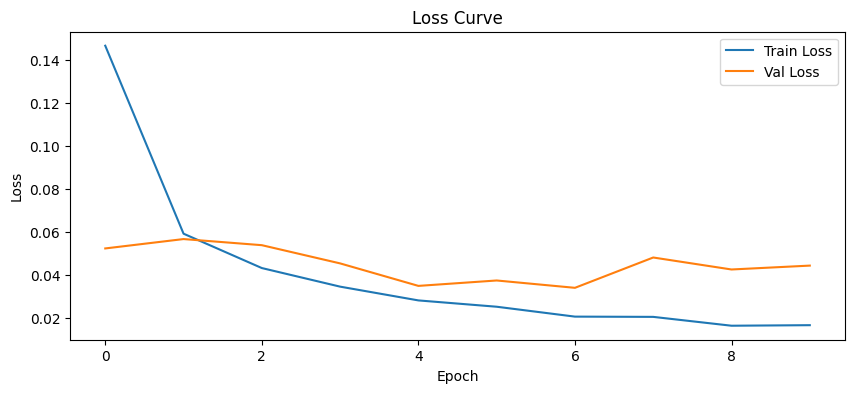

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

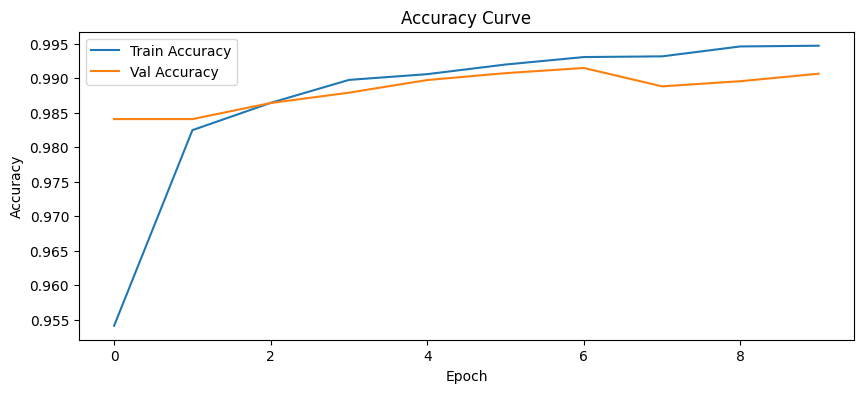

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Evaluation
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)


cm = confusion_matrix(y_test, y_pred)

print("\nClass-wise Accuracy:")

for i in range(10):
    acc = cm[i,i] / np.sum(cm[i])
    print(f"Digit {i}: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

Class-wise Accuracy:
Digit 0: 0.9929
Digit 1: 0.9912
Digit 2: 0.9952
Digit 3: 0.9960
Digit 4: 0.9857
Digit 5: 0.9821
Digit 6: 0.9937
Digit 7: 0.9883
Digit 8: 0.9969
Digit 9: 0.9901


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



RNN


In [ ]:
!pip install scikeras

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from scikeras.wrappers import KerasClassifier

In [35]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0
embarked,2


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6244 - loss: 0.7457 - val_accuracy: 0.5730 - val_loss: 0.6539
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6581 - loss: 0.6192 - val_accuracy: 0.6629 - val_loss: 0.5631
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7063 - loss: 0.5672 - val_accuracy: 0.8090 - val_loss: 0.5098
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7576 - loss: 0.5303 - val_accuracy: 0.8090 - val_loss: 0.4719
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7769 - loss: 0.5142 - val_accuracy: 0.7921 - val_loss: 0.4459


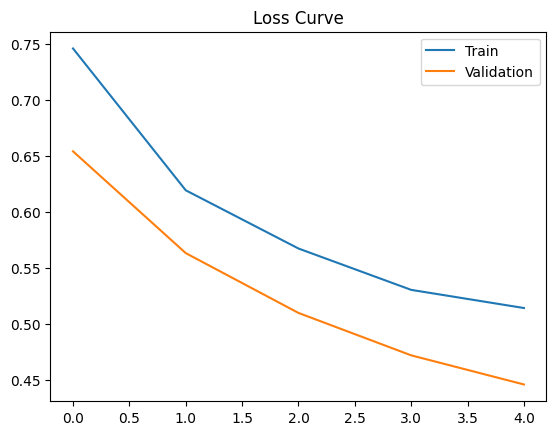

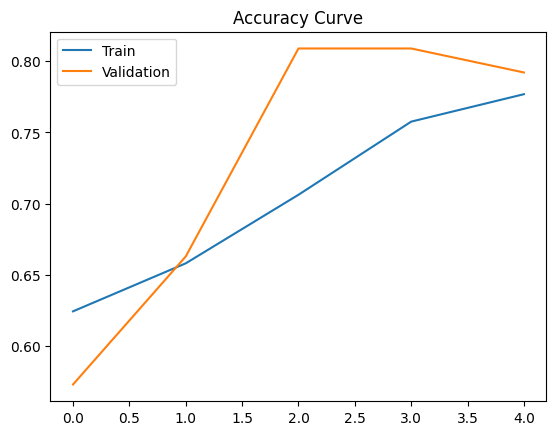

In [58]:
# ANN
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

# Load titanic dataset
import seaborn as sns

df = sns.load_dataset("titanic")
print(df.head())

# Perform Preprocessing
data = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy() # Explicitly create a copy

# Handle missing value
data['age'] = data['age'].fillna(data['age'].mean()) # Assign directly instead of inplace=True
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0]) # Assign directly instead of inplace=True

# Encode categorical variables
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['embarked'] = data['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Split into X and y
X = data.drop('survived', axis=1)
y = data['survived']

# Train:Vali:Test (70:20:10)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

######### Build ANN Model ##############
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

######## Compile Model ############
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

######## Train Model (50 epochs, batch size 32) @
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=5,
                    batch_size=32)

import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.legend(['Train', 'Validation'])
plt.show()

In [59]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        56
           1       0.73      0.65      0.69        34

    accuracy                           0.78        90
   macro avg       0.77      0.75      0.76        90
weighted avg       0.77      0.78      0.77        90



/tmp/ipykernel_11646/2114048657.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].mean(), inplace=True)
/tmp/ipykernel_11646/2114048657.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.5120 - loss: 0.7190 - val_accuracy: 0.7303 - val_loss: 0.6105
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7255 - loss: 0.5864 - val_accuracy: 0.7865 - val_loss: 0.5142
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7721 - loss: 0.5248 - val_accuracy: 0.7809 - val_loss: 0.4775
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7592 - loss: 0.5045 - val_accuracy: 0.7753 - val_loss: 0.4599
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7640 - loss: 0.4967 - val_accuracy: 0.7921 - val_loss: 0.4510
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7769 - loss: 0.4876 - val_accuracy: 0.7697 - val_loss: 0.4470
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7705 - loss: 0.4873 - val_accuracy: 0.7865 - val_loss: 0.4402
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7624 - loss: 0.4942 - val_accuracy: 0.8090 - v

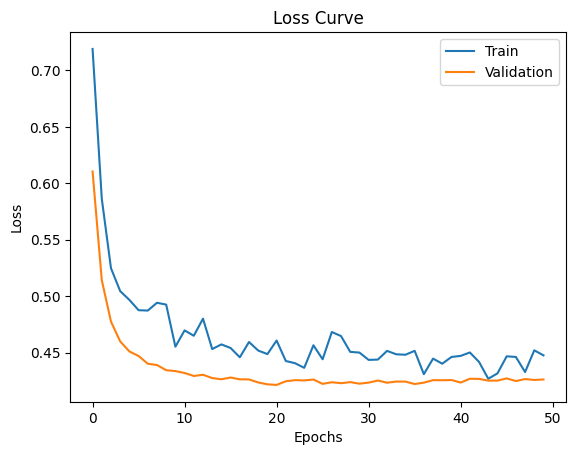

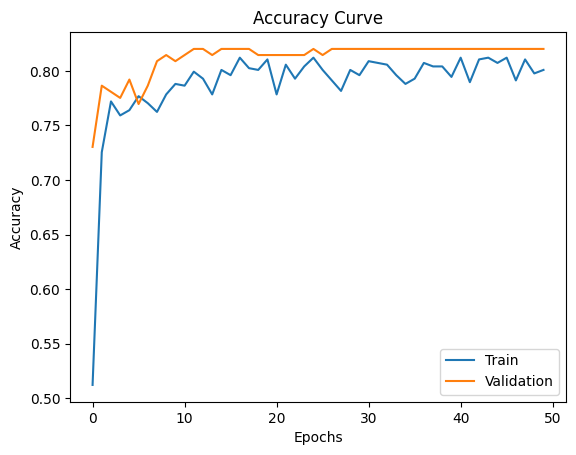

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        60
           1       0.87      0.67      0.75        30

    accuracy                           0.86        90
   macro avg       0.86      0.81      0.83        90
weighted avg       0.86      0.86      0.85        90



In [60]:
# RNN
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout


# ==============================
# 2. Load Dataset
# ==============================
data = sns.load_dataset('titanic')

# Select only important columns
data = data[['survived','pclass','sex','age','fare','embarked']]


# ==============================
# 3. Handle Missing Values
# ==============================

# Fill missing age with mean
data['age'].fillna(data['age'].mean(), inplace=True)

# Fill missing embarked with most frequent value
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)


# ==============================
# 4. Encode Categorical Variables
# ==============================

# Convert categorical columns into numeric
data = pd.get_dummies(data, drop_first=True)


# ==============================
# 5. Split Features and Target
# ==============================

X = data.drop('survived', axis=1)
y = data['survived']


# ==============================
# 6. Train-Validation-Test Split (70-20-10)
# ==============================

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# Second split: from 30% → 20% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3)


# ==============================
# 7. Feature Scaling
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# ==============================
# 8. Reshape Data for RNN
# ==============================

# RNN expects 3D input: (samples, timesteps, features)
# Here we use timestep = 1

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val   = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test  = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


# ==============================
# 9. Build RNN Model
# ==============================

model = Sequential()

# First RNN layer (64 neurons, tanh activation)
model.add(SimpleRNN(64, activation='tanh', return_sequences=True,
                    input_shape=(1, X_train.shape[2])))
model.add(Dropout(0.5))  # 50% dropout

# Second RNN layer (32 neurons, relu activation)
model.add(SimpleRNN(32, activation='relu'))
model.add(Dropout(0.2))  # 20% dropout

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))


# ==============================
# 10. Compile Model
# ==============================

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# ==============================
# 11. Train Model
# ==============================

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32)


# ==============================
# 12. Plot Loss and Accuracy Curves
# ==============================

# Loss Curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy Curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


# ==============================
# 13. Evaluate on Test Data
# ==============================

y_pred = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_pred > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred))

/tmp/ipykernel_11646/2654191195.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].mean(), inplace=True)
/tmp/ipykernel_11646/2654191195.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6356 - loss: 0.6860 - val_accuracy: 0.7247 - val_loss: 0.6743
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6709 - loss: 0.6699 - val_accuracy: 0.7416 - val_loss: 0.6499
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7063 - loss: 0.6436 - val_accuracy: 0.7584 - val_loss: 0.6089
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7448 - loss: 0.6047 - val_accuracy: 0.7978 - val_loss: 0.5497
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7785 - loss: 0.5509 - val_accuracy: 0.8315 - val_loss: 0.4911
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7817 - loss: 0.5175 - val_accuracy: 0.8202 - val_loss: 0.4595
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7929 - loss: 0.4917 - val_accuracy: 0.8090 - val_loss: 0.4423
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7865 - loss: 0.4862 - val_accuracy: 0.7921 - va

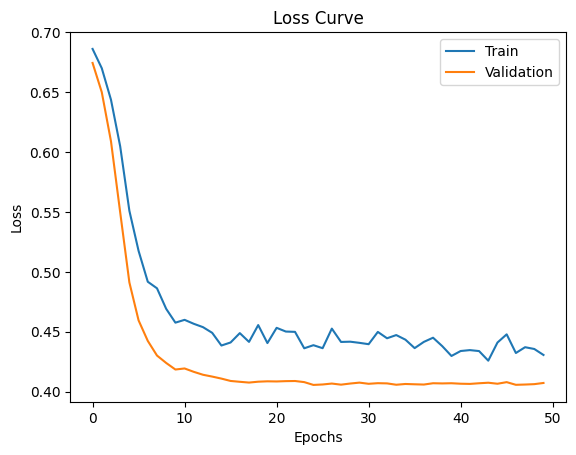

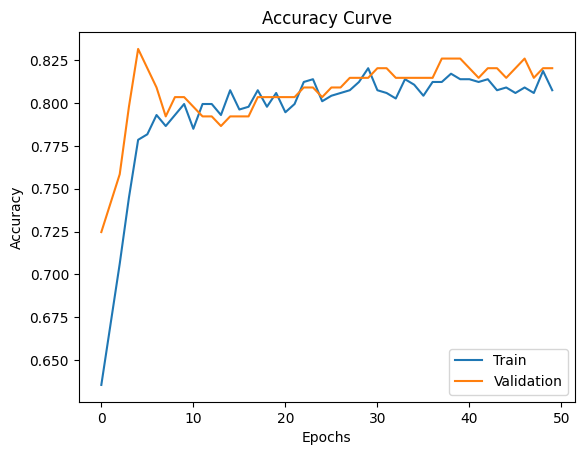

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.91      0.80        45
           1       0.88      0.64      0.74        45

    accuracy                           0.78        90
   macro avg       0.80      0.78      0.77        90
weighted avg       0.80      0.78      0.77        90



In [61]:
# LSTM
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# ==============================
# 2. Load Dataset
# ==============================
data = sns.load_dataset('titanic')

# Select useful columns
data = data[['survived','pclass','sex','age','fare','embarked']]


# ==============================
# 3. Handle Missing Values
# ==============================

# Fill missing age with mean
data['age'].fillna(data['age'].mean(), inplace=True)

# Fill missing embarked with mode
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)


# ==============================
# 4. Encode Categorical Variables
# ==============================

# Convert categorical to numeric
data = pd.get_dummies(data, drop_first=True)


# ==============================
# 5. Split Features and Target
# ==============================

X = data.drop('survived', axis=1)
y = data['survived']


# ==============================
# 6. Train-Validation-Test Split (70-20-10)
# ==============================

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# Second split: 30% → 20% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3)


# ==============================
# 7. Feature Scaling
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# ==============================
# 8. Reshape Data for LSTM
# ==============================

# LSTM expects 3D input: (samples, timesteps, features)
# Using timestep = 1

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val   = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test  = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


# ==============================
# 9. Build LSTM Model
# ==============================

model = Sequential()

# First LSTM layer (64 neurons, tanh activation)
model.add(LSTM(64, activation='tanh', return_sequences=True,
               input_shape=(1, X_train.shape[2])))
model.add(Dropout(0.5))   # 50% dropout

# Second LSTM layer (32 neurons, relu activation)
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))   # 20% dropout

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))


# ==============================
# 10. Compile Model
# ==============================

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# ==============================
# 11. Train Model
# ==============================

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32)


# ==============================
# 12. Plot Loss & Accuracy Curves
# ==============================

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


# ==============================
# 13. Evaluate Model on Test Data
# ==============================

y_pred = model.predict(X_test)

# Convert probability to 0/1
y_pred = (y_pred > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred))